# Test Algorithm Scaling

In [1]:
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

from hirank import RankOD, BootstrapRankOD

In [2]:
# Define methods
rank = RankOD(mode="rank")
boot = BootstrapRankOD(5)
sun = RankOD(mode = "sun")
lof_ball = LocalOutlierFactor(novelty=True, algorithm="ball_tree")
lof_kd = LocalOutlierFactor(novelty=True, algorithm="kd_tree")
iso = IsolationForest()
methods = [rank, boot, sun, lof_ball, lof_kd, iso]
method_names = ["Rank", "Bootstrap", "Sun", "LOF Ball", "LOF KD", "ISO"]

## Test Scaling with respect to dimension

In [3]:
dimensions = np.linspace(2, 500, 5, dtype="int")
REPEAT = 10

# Warm cache
for method in methods:
    X = np.random.random((200, 30))
    X_test = np.random.random((200, 30))
    with warnings.catch_warnings() as caught:
        warnings.simplefilter("ignore", category=UserWarning)
        method.fit(X)
        method.predict(X_test)

results = []
for d, dim in enumerate(dimensions):
    for r in range(REPEAT):
        X_train, y_train = make_blobs(n_samples=10000, centers=30, n_features=dim)
        X_test, y_test = make_blobs(n_samples=1000, centers=5, n_features=dim)
        for m, method in enumerate(methods):
            start = time.perf_counter()
            method.fit(X_train)
            end = time.perf_counter()
            fit_time = end - start

            start = time.perf_counter()
            method.predict(X_test)
            end = time.perf_counter()
            pred_time = end - start

            results.append([method_names[m], dim, r, fit_time, pred_time])

df = pd.DataFrame(results, columns=["Method", "Dimension", "Iteration", "Fit Time", "Predict Time"])
df

,Method,Dimension,Iteration,Fit Time,Predict Time
0,Rank,2,0,0.352030,0.743240
1,Bootstrap,2,0,0.406165,2.789823
2,Sun,2,0,0.065728,0.602370
3,LOF Ball,2,0,0.069190,0.006917
4,LOF KD,2,0,0.024302,0.002508
...,...,...,...,...,...
295,Bootstrap,500,9,0.581680,3.155457
296,Sun,500,9,0.142424,0.604764
297,LOF Ball,500,9,20.170421,5.228880
298,LOF KD,500,9,4.260484,7.014993


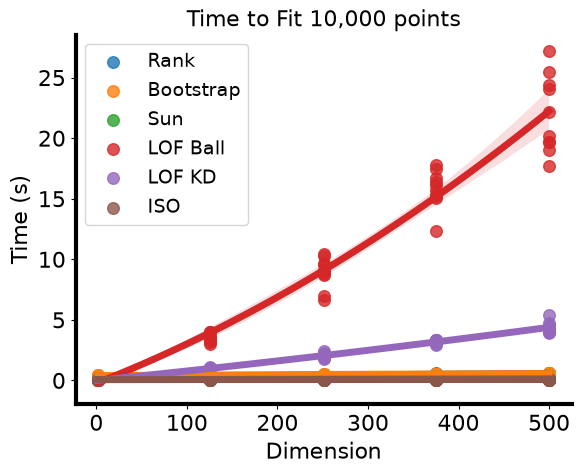

In [4]:
fig, ax = plt.subplots()
for method in method_names:
    sns.regplot(df[df["Method"] == method], x="Dimension", y="Fit Time", order=2, scatter_kws={"s": 70}, line_kws={"linewidth": 5}, label=method, ax=ax)
ax.legend(fontsize=14)
ax.set_title("Time to Fit 10,000 points", fontsize=16)
ax.set_ylabel("Time (s)", fontsize=16)
ax.set_xlabel("Dimension", fontsize=16)
ax.tick_params(labelsize=16)
for spine in ['right', 'top']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(3)
plt.savefig("timing_d_fit.pdf")

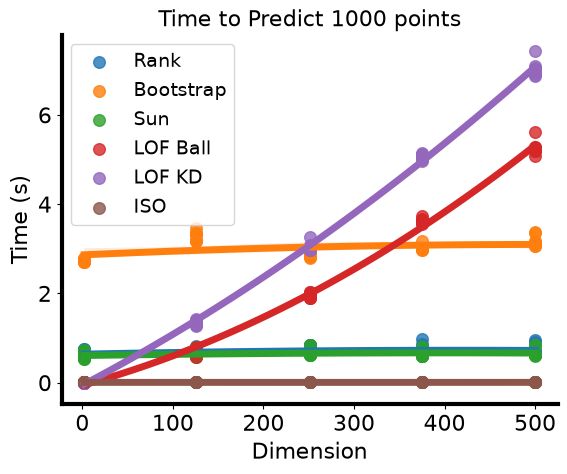

In [5]:
fig, ax = plt.subplots()
for method in method_names:
    sns.regplot(df[df["Method"] == method], x="Dimension", y="Predict Time", order=2, scatter_kws={"s": 70}, line_kws={"linewidth": 5}, label=method, ax=ax)
ax.legend(fontsize=14)
ax.set_title("Time to Predict 1000 points", fontsize=16)
ax.set_ylabel("Time (s)", fontsize=16)
ax.set_xlabel("Dimension", fontsize=16)
ax.tick_params(labelsize=16)
for spine in ['right', 'top']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(3)
plt.savefig("timing_d_pred.pdf")

## Scaling with respect to dataset size

In [6]:
sizes = np.linspace(5000, 50000, 5, dtype="int")
dim = 16
REPEAT = 10

# Warm cache
for method in methods:
    X = np.random.random((200, 30))
    X_test = np.random.random((200, 30))
    with warnings.catch_warnings() as caught:
        warnings.simplefilter("ignore", category=UserWarning)
        method.fit(X)
        method.predict(X_test)

results = []
for n, num in enumerate(sizes):
    for r in range(REPEAT):
        X_train, y_train = make_blobs(n_samples=num, centers=30, n_features=dim)
        X_test, y_test = make_blobs(n_samples=num//10, centers=5, n_features=dim)
        for m, method in enumerate(methods):
            start = time.perf_counter()
            method.fit(X_train)
            end = time.perf_counter()
            fit_time = end - start

            start = time.perf_counter()
            method.predict(X_test)
            end = time.perf_counter()
            pred_time = end - start

            results.append([str(method_names[m]), num, r, fit_time, pred_time])

df = pd.DataFrame(results, columns=["Method", "N", "Iteration", "Fit Time", "Predict Time"])
df

,Method,N,Iteration,Fit Time,Predict Time
0,Rank,5000,0,0.204673,0.575156
1,Bootstrap,5000,0,0.352283,2.872269
2,Sun,5000,0,0.055467,0.602157
3,LOF Ball,5000,0,0.098946,0.013977
4,LOF KD,5000,0,0.045366,0.027700
...,...,...,...,...,...
295,Bootstrap,50000,9,1.010740,3.495997
296,Sun,50000,9,0.251007,1.311627
297,LOF Ball,50000,9,4.592588,0.725934
298,LOF KD,50000,9,1.698078,1.369546


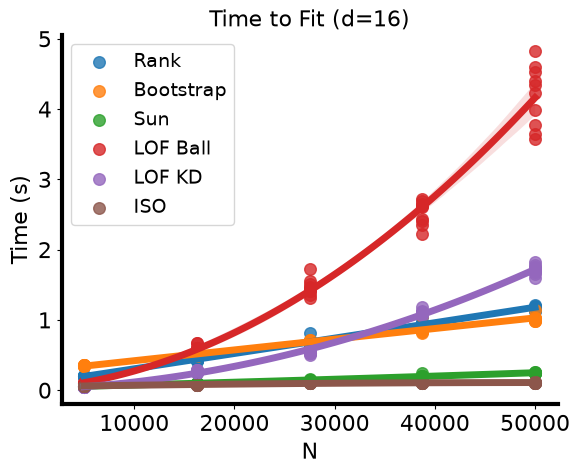

In [7]:
fig, ax = plt.subplots()
for method in method_names:
    sns.regplot(df[df["Method"] == method], x="N", y="Fit Time", order=2, scatter_kws={"s": 70}, line_kws={"linewidth": 5}, label=method, ax=ax)
ax.legend(fontsize=14)
ax.set_title(f"Time to Fit (d={dim})", fontsize=16)
ax.set_ylabel("Time (s)", fontsize=16)
ax.set_xlabel("N", fontsize=16)
ax.tick_params(labelsize=16)
for spine in ['right', 'top']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(3)
plt.savefig("timing_n_fit.pdf")

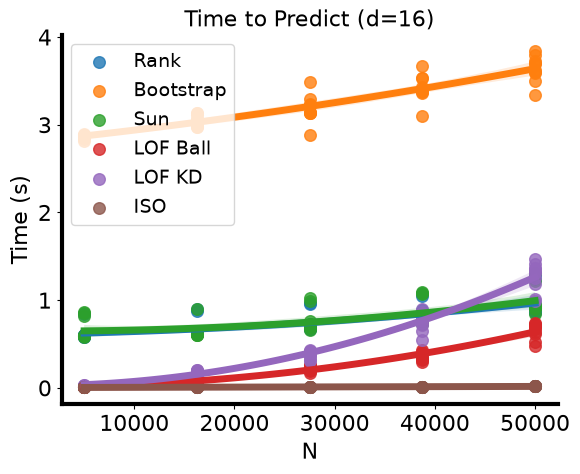

In [9]:
fig, ax = plt.subplots()
for method in method_names:
    sns.regplot(df[df["Method"] == method], x="N", y="Predict Time", order=2, scatter_kws={"s": 70}, line_kws={"linewidth": 5}, label=method, ax=ax)
ax.legend(loc="upper left", fontsize=14)
ax.set_title(f"Time to Predict (d={dim})", fontsize=16)
ax.set_ylabel("Time (s)", fontsize=16)
ax.set_xlabel("N", fontsize=16)
ax.tick_params(labelsize=16)
for spine in ['right', 'top']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(3)
plt.savefig("timing_n_pred.pdf")